#  Robust Electricity Theft Detection Under Data-Poisoning Attacks
##  Setup, Data Preparation & Poison Injection Pipeline

**Student:** Surekha Suresh | C00317211  
**Supervisor:** Milu Philip  
**Programme:** MSc in Data Science (SE61H) — SETU Carlow  
**Dataset:** SGCC — State Grid Corporation of China (Zheng et al., 2018)

---

### Objectives
- [ ] Install and verify all dependencies
- [ ] Download and load the SGCC dataset
- [ ] Exploratory Data Analysis (EDA)
- [ ] Handle missing values
- [ ] Normalise and preprocess features
- [ ] Stratified train/val/test split (70/15/15)
- [ ] Build label-flipping poison injector (0%, 10%, 20%, 30%)
- [ ] Verify poison injection is working correctly

---
**Citation:** Zheng, Z., Yang, Y., Niu, X., Dai, H., & Zhou, Y. (2018). Wide and deep convolutional neural networks for electricity-theft detection to secure smart grids. *IEEE Transactions on Industrial Informatics, 14*(4), 1606–1615.

## Cell 1 — Install Dependencies

In [ ]:
# Install all required libraries
# Run this cell once, then restart kernel if needed

!pip3 install pandas numpy matplotlib seaborn scikit-learn imbalanced-learn scipy tqdm

## Cell 2 — Imports & Global Seed

>  **Important:** Always set random seeds for reproducibility. Your paper must report results that can be replicated.

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import os
import warnings
from tqdm import tqdm

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE

warnings.filterwarnings('ignore')

# ── Global random seed (CRITICAL for reproducibility) ──────────────────────────
SEED = 42
np.random.seed(SEED)

# ── Plotting style ─────────────────────────────────────────────────────────────
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

print('All libraries imported successfully')
print(f'   NumPy  : {np.__version__}')
print(f'   Pandas : {pd.__version__}')
print(f'   Random seed set to: {SEED}')

All libraries imported successfully
   NumPy  : 2.4.6
   Pandas : 3.0.3
   Random seed set to: 42


## Cell 3 — Download SGCC Dataset

**Source:** https://github.com/henryRDlab/ElectricityTheftDetection  

The SGCC dataset consists of:
- `data.zip` + `data.z01` + `data.z02` — download all three and extract together
- After extraction you will have a single CSV file
- Rows = customers (42,372 total), Columns = daily readings + `FLAG` label
- `FLAG = 0` → Normal (benign), `FLAG = 1` → Electricity thief

> 📁 Place your extracted CSV in the same folder as this notebook and update `DATA_PATH` below.

In [ ]:
# ── Update this path to your extracted SGCC CSV file ──────────────────────────
DATA_PATH = '/Users/surekha/Documents/projects folder/ElectricityTheftDetection/data.csv'   # <-- change filename if yours is different

# ── Load dataset ───────────────────────────────────────────────────────────────
print(f'Loading dataset from: {DATA_PATH}')
df_raw = pd.read_csv(DATA_PATH)

print(f'\n Raw dataset shape: {df_raw.shape}')
print(f'   Rows (customers) : {df_raw.shape[0]:,}')
print(f'   Columns           : {df_raw.shape[1]:,}')
print(f'\nFirst 5 rows:')
df_raw.head()

## Cell 4 — Exploratory Data Analysis (EDA)

Key questions:
1. How many theft vs normal customers? (class imbalance)
2. How many missing values are there?
3. What does the consumption distribution look like?

  CLASS DISTRIBUTION
  Normal  (FLAG=0):  38,757  (91.5%)
  Theft   (FLAG=1):   3,615  (8.5%)
  Imbalance ratio : 10.7:1


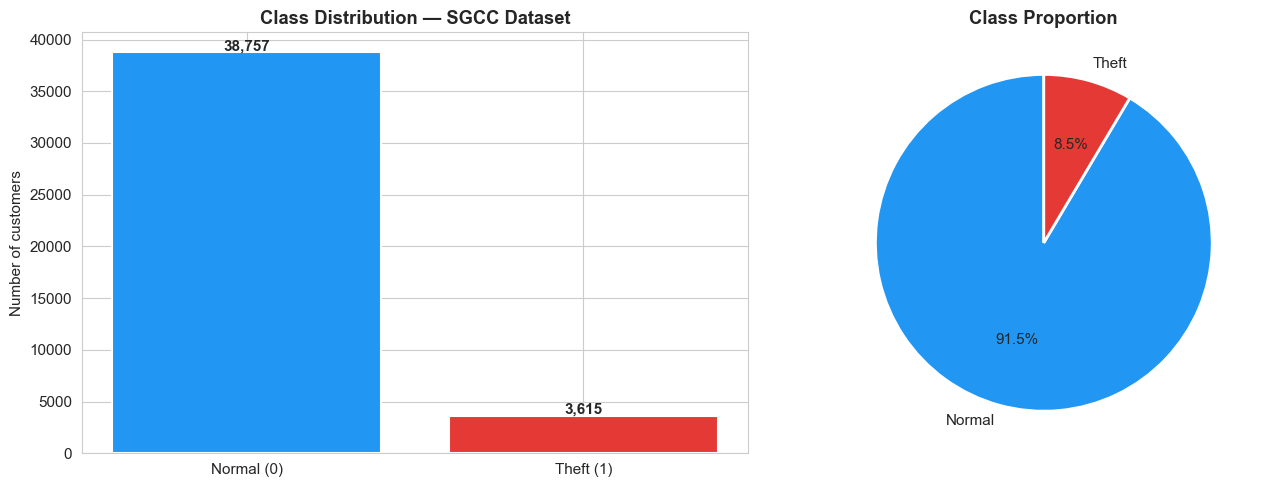

  Saved: eda_class_distribution.png


In [16]:
# ── Identify label column ──────────────────────────────────────────────────────
# In SGCC the label column is called 'FLAG' (last column)
LABEL_COL = 'FLAG'

# Separate features and labels
labels = df_raw[LABEL_COL]
features_raw = df_raw.drop(columns=[LABEL_COL])

print('=' * 55)
print('  CLASS DISTRIBUTION')
print('=' * 55)
class_counts = labels.value_counts()
print(f'  Normal  (FLAG=0): {class_counts[0]:>7,}  ({class_counts[0]/len(labels)*100:.1f}%)')
print(f'  Theft   (FLAG=1): {class_counts[1]:>7,}  ({class_counts[1]/len(labels)*100:.1f}%)')
print(f'  Imbalance ratio : {class_counts[0]/class_counts[1]:.1f}:1')
print('=' * 55)

# ── Class distribution bar chart ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
colors = ['#2196F3', '#E53935']
axes[0].bar(['Normal (0)', 'Theft (1)'], class_counts.values, color=colors, edgecolor='white', linewidth=1.5)
axes[0].set_title('Class Distribution — SGCC Dataset', fontweight='bold')
axes[0].set_ylabel('Number of customers')
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 200, f'{v:,}', ha='center', fontweight='bold')

# Pie chart
axes[1].pie(class_counts.values, labels=['Normal', 'Theft'],
            colors=colors, autopct='%1.1f%%', startangle=90,
            wedgeprops=dict(edgecolor='white', linewidth=2))
axes[1].set_title('Class Proportion', fontweight='bold')

plt.tight_layout()
plt.savefig('eda_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('  Saved: eda_class_distribution.png')


 Missing Value Summary
   Total columns      : 1,035
   Columns with NaN   : 1,034
   Overall NaN rate   : 25.62%

   Top 10 columns with most missing values:
           Missing Count  Missing %
2014/10/3          42357  99.964599
2014/3/19          21505  50.752856
2014/2/28          20985  49.525630
2014/3/4           20820  49.136222
2014/3/3           20806  49.103181
2014/4/19          20633  48.694893
2014/2/20          20536  48.465968
2014/2/23          20494  48.366846
2014/2/24          20326  47.970358
2014/3/2           20224  47.729633


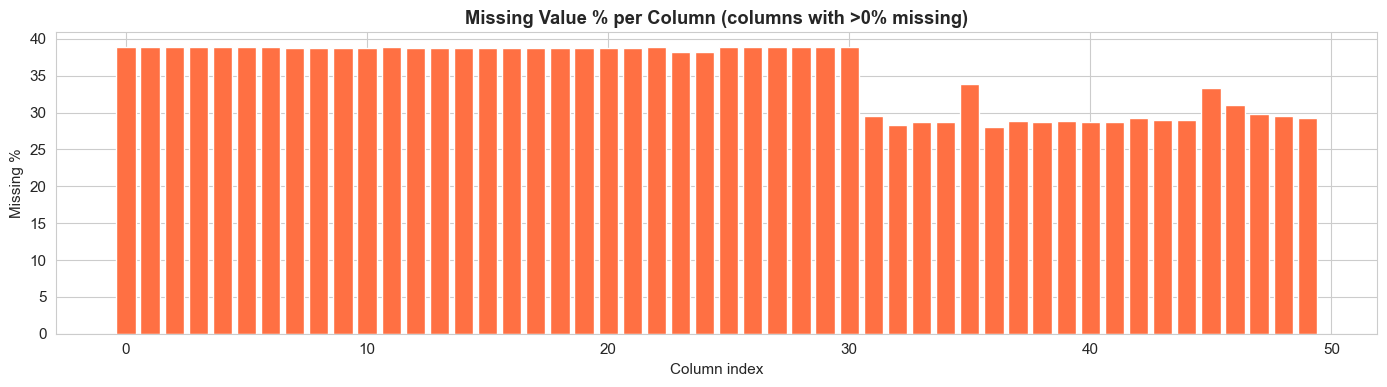

  Saved: eda_missing_values.png


In [56]:
# ── Missing value analysis ─────────────────────────────────────────────────────
missing = features_raw.isnull().sum()
missing_pct = (missing / len(features_raw) * 100)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)

print(f'\n Missing Value Summary')
print(f'   Total columns      : {features_raw.shape[1]:,}')
print(f'   Columns with NaN   : {len(missing_df):,}')
print(f'   Overall NaN rate   : {features_raw.isnull().sum().sum() / features_raw.size * 100:.2f}%')

if len(missing_df) > 0:
    print(f'\n   Top 10 columns with most missing values:')
    print(missing_df.head(10).to_string())
    
    # Plot missing values heatmap (sample of columns)
    plt.figure(figsize=(14, 4))
    missing_sample = missing_pct[missing_pct > 0].head(50)
    plt.bar(range(len(missing_sample)), missing_sample.values, color='#FF7043')
    plt.title('Missing Value % per Column (columns with >0% missing)', fontweight='bold')
    plt.xlabel('Column index')
    plt.ylabel('Missing %')
    plt.tight_layout()
    plt.savefig('eda_missing_values.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('  Saved: eda_missing_values.png')
else:
    print('      No missing values found!')

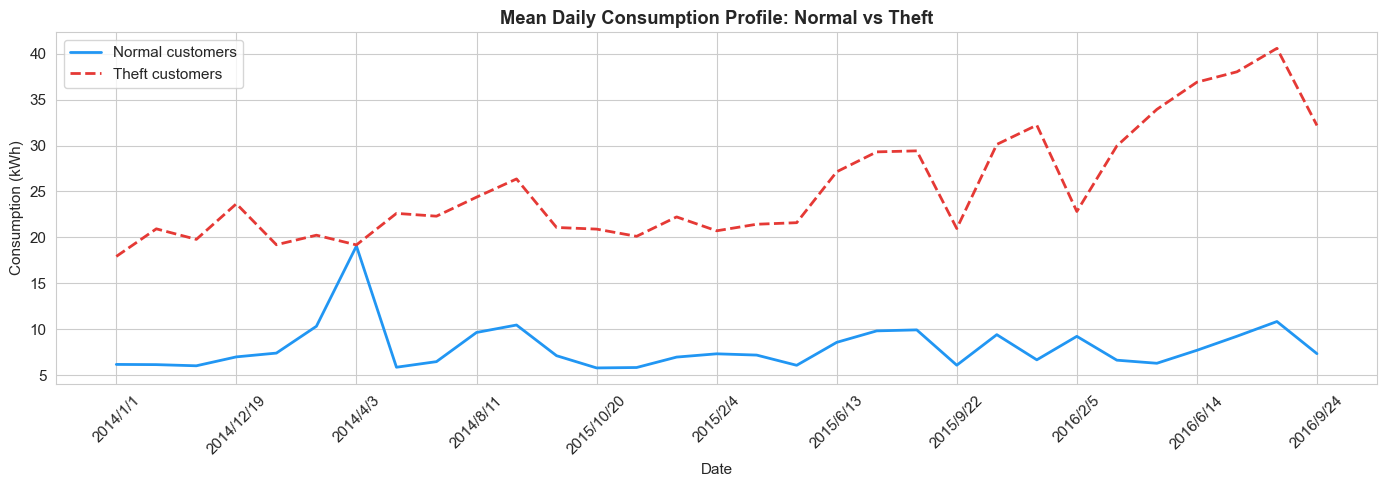

  Saved: eda_consumption_profile.png


In [5]:
# ── Consumption profile: Normal vs Theft ──────────────────────────────────────
# Plot mean daily consumption across the time window for each class

# Get numeric columns only (daily readings)
date_cols = [c for c in features_raw.columns if c not in ['CONS_NO']]

normal_mean = features_raw[labels == 0][date_cols].mean()
theft_mean  = features_raw[labels == 1][date_cols].mean()

# Sample every 30 days for readability
step = max(1, len(date_cols) // 30)
idx  = range(0, len(date_cols), step)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot([date_cols[i] for i in idx], [normal_mean.iloc[i] for i in idx],
        label='Normal customers', color='#2196F3', linewidth=2)
ax.plot([date_cols[i] for i in idx], [theft_mean.iloc[i] for i in idx],
        label='Theft customers', color='#E53935', linewidth=2, linestyle='--')
ax.set_title('Mean Daily Consumption Profile: Normal vs Theft', fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Consumption (kWh)')
ax.legend()
ax.set_xticks(ax.get_xticks()[::max(1, len(ax.get_xticks())//8)])
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('eda_consumption_profile.png', dpi=150, bbox_inches='tight')
plt.show()
print('  Saved: eda_consumption_profile.png')

## Cell 5 — Data Preprocessing

Steps:
1. **Impute** missing values with column median (safer than mean for skewed data)
2. **Scale** features with StandardScaler (zero mean, unit variance)
3. Keep a copy of raw labels before any poisoning

In [18]:
# # ── Drop non-numeric columns (CONS_NO = customer ID hash) ─────────────────────
# features_numeric = features_raw.select_dtypes(include=['number'])

# dropped_cols = [c for c in features_raw.columns
#                if c not in features_numeric.columns]
# print(f'Dropped non-numeric columns: {dropped_cols}')
# print(f'Numeric features shape: {features_numeric.shape}')

# # ── Step 1: Impute missing values ──────────────────────────────────────────────
# print('Step 1: Imputing missing values with column median...')
# imputer = SimpleImputer(strategy='median')
# X_imputed = imputer.fit_transform(features_numeric)
# print(f'           Shape after imputation: {X_imputed.shape}')

# # ── Step 2: Standard scaling ───────────────────────────────────────────────────
# print('\nStep 2: Scaling features (StandardScaler)...')
# scaler = StandardScaler()
# X_scaled = scaler.fit_transform(X_imputed)
# print(f'           Feature mean ≈ {X_scaled.mean():.4f} (should be ~0.0)')
# print(f'           Feature std  ≈ {X_scaled.std():.4f}  (should be ~1.0)')

# # ── Step 3: Store clean labels ─────────────────────────────────────────────────
# y_clean = labels.values.copy()
# print(f'\nStep 3: Clean labels stored.')
# print(f'        Normal (0): {(y_clean == 0).sum():,}')
# print(f'        Theft  (1): {(y_clean == 1).sum():,}')
# print(f'\n   Preprocessing complete. X: {X_scaled.shape}, y: {y_clean.shape}')


# ── Drop non-numeric columns (CONS_NO = customer ID hash) ─────────────────────
features_numeric = features_raw.select_dtypes(include=['number'])
dropped_cols = [c for c in features_raw.columns
               if c not in features_numeric.columns]
print(f'Dropped non-numeric columns: {dropped_cols}')
print(f'Numeric features shape: {features_numeric.shape}')

# ── Step 1: Impute missing values ──────────────────────────────────────────────
print('Step 1: Imputing missing values with column median...')
imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(features_numeric)
print(f'        ✅ Shape after imputation: {X_imputed.shape}')

# ── Step 1b: Extract statistical features (on RAW imputed data) ───────────────
# Must be here — BEFORE scaling — so kWh values are real
print('\nStep 1b: Extracting statistical features for shallow ML...')
from scipy import stats

def extract_features(X):
    features = np.zeros((X.shape[0], 12))
    features[:, 0]  = np.mean(X, axis=1)
    features[:, 1]  = np.std(X, axis=1)
    features[:, 2]  = np.min(X, axis=1)
    features[:, 3]  = np.max(X, axis=1)
    features[:, 4]  = np.sum(X, axis=1)
    features[:, 5]  = np.max(X, axis=1) / (np.mean(X, axis=1) + 1e-9)
    features[:, 6]  = stats.skew(X, axis=1)
    features[:, 7]  = stats.kurtosis(X, axis=1)
    features[:, 8]  = (X <= 0).sum(axis=1)
    features[:, 9]  = np.median(X, axis=1)
    features[:, 10] = np.percentile(X, 25, axis=1)
    features[:, 11] = np.percentile(X, 75, axis=1)
    return features

X_feat_all = extract_features(X_imputed)
print(f'        ✅ Statistical features shape: {X_feat_all.shape}')
print(f'           Mean consumption : {X_feat_all[:,0].mean():.3f} kWh')
print(f'           Zero/neg days    : {X_feat_all[:,8].mean():.3f}')

# ── Step 2: Standard scaling (raw sequences for deep learning) ────────────────
print('\nStep 2: Scaling features (StandardScaler)...')
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)
print(f'        ✅ Feature mean ≈ {X_scaled.mean():.4f} (should be ~0.0)')
print(f'           Feature std  ≈ {X_scaled.std():.4f}  (should be ~1.0)')

# ── Step 3: Store clean labels ─────────────────────────────────────────────────
y_clean = labels.values.copy()
print(f'\nStep 3: Clean labels stored.')
print(f'        Normal (0): {(y_clean == 0).sum():,}')
print(f'        Theft  (1): {(y_clean == 1).sum():,}')
print(f'\n✅ Preprocessing complete. X: {X_scaled.shape}, y: {y_clean.shape}')

Dropped non-numeric columns: ['CONS_NO']
Numeric features shape: (42372, 1034)
Step 1: Imputing missing values with column median...
        ✅ Shape after imputation: (42372, 1034)

Step 1b: Extracting statistical features for shallow ML...
        ✅ Statistical features shape: (42372, 12)
           Mean consumption : 8.149 kWh
           Zero/neg days    : 136.614

Step 2: Scaling features (StandardScaler)...
        ✅ Feature mean ≈ 0.0000 (should be ~0.0)
           Feature std  ≈ 1.0000  (should be ~1.0)

Step 3: Clean labels stored.
        Normal (0): 38,757
        Theft  (1): 3,615

✅ Preprocessing complete. X: (42372, 1034), y: (42372,)


## Cell 6 — Stratified Train / Validation / Test Split (70 / 15 / 15)

Using **stratified** splitting to preserve class ratio in each split — critical given the class imbalance.

In [19]:
# ── Stratified 70/15/15 split ──────────────────────────────────────────────────

# First: 70% train, 30% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X_scaled, y_clean,
    test_size=0.30,
    stratify=y_clean,
    random_state=SEED
)

# Then: split temp 50/50 → 15% val, 15% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=SEED
)

print('=' * 55)
print('  TRAIN / VAL / TEST SPLIT SUMMARY')
print('=' * 55)
for name, X, y in [('Train (70%)', X_train, y_train),
                    ('Val   (15%)', X_val,   y_val),
                    ('Test  (15%)', X_test,  y_test)]:
    theft_pct = (y == 1).sum() / len(y) * 100
    print(f'  {name}: {len(y):>6,} samples  |  theft: {theft_pct:.1f}%')
print('=' * 55)
print('\n     Class ratio preserved across all splits (stratified)')
print(f'\n  Shapes:')
print(f'    X_train: {X_train.shape}  y_train: {y_train.shape}')
print(f'    X_val  : {X_val.shape}  y_val  : {y_val.shape}')
print(f'    X_test : {X_test.shape}  y_test : {y_test.shape}')

  TRAIN / VAL / TEST SPLIT SUMMARY
  Train (70%): 29,660 samples  |  theft: 8.5%
  Val   (15%):  6,356 samples  |  theft: 8.5%
  Test  (15%):  6,356 samples  |  theft: 8.5%

     Class ratio preserved across all splits (stratified)

  Shapes:
    X_train: (29660, 1034)  y_train: (29660,)
    X_val  : (6356, 1034)  y_val  : (6356,)
    X_test : (6356, 1034)  y_test : (6356,)


## Cell 7 — Handle Class Imbalance with SMOTE

> **Apply SMOTE only to the training set — never to val or test.**  
> Applying it to val/test would leak synthetic data into evaluation and inflate your results.

SGCC is heavily imbalanced (~91% normal, ~9% theft). Without balancing, models learn to just predict "normal" and still get 91% accuracy — which is useless for theft detection.

Applying SMOTE to training set...
  Before SMOTE → Normal: 27,130  |  Theft: 2,530
  After SMOTE  → Normal: 27,130  |  Theft: 27,130
  New training shape: (54260, 1034)


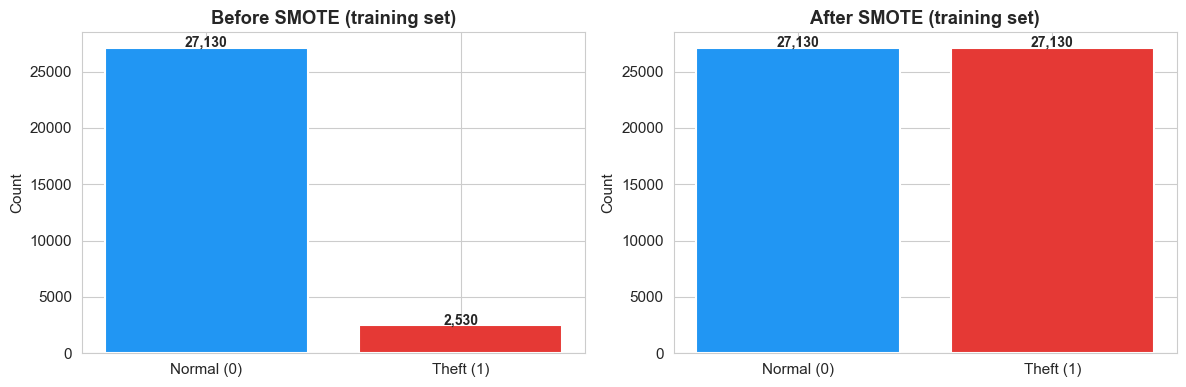

  Saved: eda_smote_balance.png


In [8]:
# ── Apply SMOTE to training set only ──────────────────────────────────────────
print('Applying SMOTE to training set...')
print(f'  Before SMOTE → Normal: {(y_train==0).sum():,}  |  Theft: {(y_train==1).sum():,}')

smote = SMOTE(random_state=SEED)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print(f'  After SMOTE  → Normal: {(y_train_bal==0).sum():,}  |  Theft: {(y_train_bal==1).sum():,}')
print(f'  New training shape: {X_train_bal.shape}')

# ── Visualise before / after ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
colors = ['#2196F3', '#E53935']

for ax, y, title in [
    (axes[0], y_train,     'Before SMOTE (training set)'),
    (axes[1], y_train_bal, 'After SMOTE (training set)')
]:
    counts = pd.Series(y).value_counts().sort_index()
    ax.bar(['Normal (0)', 'Theft (1)'], counts.values, color=colors, edgecolor='white', linewidth=1.5)
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Count')
    for i, v in enumerate(counts.values):
        ax.text(i, v + 50, f'{v:,}', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('eda_smote_balance.png', dpi=150, bbox_inches='tight')
plt.show()
print('  Saved: eda_smote_balance.png')

## Cell 7.1 — Feature Engineering


In [10]:
# ── Cell 8: Statistical Feature Extraction ─────────────────────────────────
# For shallow ML models (RF, AdaBoost, SVM)
# Raw 1034-column sequences → 12 meaningful statistical features per customer

from scipy import stats

def extract_features(X):
    """
    Convert raw daily readings into 12 statistical features.
    Used for shallow ML only. Deep learning uses raw sequences.
    """
    features = np.zeros((X.shape[0], 12))
    features[:, 0]  = np.mean(X, axis=1)
    features[:, 1]  = np.std(X, axis=1)
    features[:, 2]  = np.min(X, axis=1)
    features[:, 3]  = np.max(X, axis=1)
    features[:, 4]  = np.sum(X, axis=1)
    features[:, 5]  = np.max(X, axis=1) / (np.mean(X, axis=1) + 1e-9)
    features[:, 6]  = stats.skew(X, axis=1)
    features[:, 7]  = stats.kurtosis(X, axis=1)
    features[:, 8]  = (X == 0).sum(axis=1)
    features[:, 9]  = np.median(X, axis=1)
    features[:, 10] = np.percentile(X, 25, axis=1)
    features[:, 11] = np.percentile(X, 75, axis=1)
    return features

print("Extracting statistical features...")
X_train_feat = extract_features(X_train_bal)   # use SMOTE-balanced train
X_val_feat   = extract_features(X_val)
X_test_feat  = extract_features(X_test)

print(f"  X_train_feat : {X_train_feat.shape}")
print(f"  X_val_feat   : {X_val_feat.shape}")
print(f"  X_test_feat  : {X_test_feat.shape}")
print("✅ Feature extraction complete")

Extracting statistical features...
  X_train_feat : (54260, 12)
  X_val_feat   : (6356, 12)
  X_test_feat  : (6356, 12)
✅ Feature extraction complete


In [ ]:
import os

# Check where Jupyter is currently running from
print("Current working directory:", os.getcwd())

# List what's in processed_data if it exists
if os.path.exists('processed_data'):
    print("\nFiles found:", os.listdir('processed_data'))
else:
    print("\n❌ processed_data not found here")
    # Search one level up
    if os.path.exists('../processed_data'):
        print("✅ Found at ../processed_data — fixing path...")
        os.chdir('..')
        print("New working directory:", os.getcwd())
    else:
        print("Searching for processed_data folder...")
        for root, dirs, files in os.walk(os.path.expanduser('~')):
            if 'processed_data' in dirs:
                print(f"Found at: {root}")
                break

In [ ]:
# Save statistical feature sets 
np.save('processed_data/X_train_feat.npy', X_train_feat)
np.save('processed_data/X_val_feat.npy',   X_val_feat)
np.save('processed_data/X_test_feat.npy',  X_test_feat)
print("✅ Feature files saved")

✅ Feature files saved


## Cell 8 — Poison Injection Pipeline

This is the **core experimental mechanism** of your research.

**Label-flipping attack:**
- Randomly select X% of training samples
- Flip their labels: `0 → 1` and `1 → 0`
- The model trains on poisoned data and learns wrong decision boundaries

We test four penetration levels: **0%, 10%, 20%, 30%**

> **0% = clean baseline** — this is your reference point for computing Δ

In [61]:
# ══════════════════════════════════════════════════════════════════════════════
#  POISON INJECTION FUNCTION
# ══════════════════════════════════════════════════════════════════════════════

def inject_poison(y_labels, poison_rate, seed=SEED):
    """
    Label-flipping poison attack.
    
    Args:
        y_labels   : numpy array of clean labels (0 or 1)
        poison_rate: float, fraction of labels to flip (e.g. 0.10 = 10%)
        seed       : random seed for reproducibility
    
    Returns:
        y_poisoned : numpy array with flipped labels
        flipped_idx: indices of flipped samples (for logging/analysis)
    """
    rng = np.random.default_rng(seed)
    y_poisoned = y_labels.copy()
    
    n_total  = len(y_labels)
    n_poison = int(n_total * poison_rate)
    
    # Randomly select indices to poison
    flipped_idx = rng.choice(n_total, size=n_poison, replace=False)
    
    # Flip labels: 0 → 1, 1 → 0
    y_poisoned[flipped_idx] = 1 - y_poisoned[flipped_idx]
    
    return y_poisoned, flipped_idx


# ── Generate all four poisoned training label sets ─────────────────────────────
POISON_RATES = [0.0, 0.10, 0.20, 0.30]
poisoned_labels = {}   # store all versions

print('=' * 60)
print('  POISON INJECTION RESULTS')
print('=' * 60)
print(f'  Base training set: {len(y_train_bal):,} samples (after SMOTE)\n')

for rate in POISON_RATES:
    y_pois, flipped = inject_poison(y_train_bal, rate)
    poisoned_labels[rate] = y_pois
    
    # Verify flip counts
    actual_flipped = (y_pois != y_train_bal).sum()
    label_name = 'Clean baseline' if rate == 0 else f'{int(rate*100)}% poisoning'
    
    print(f'  [{int(rate*100):>2}%] {label_name}')
    print(f'        Labels flipped  : {actual_flipped:,}')
    print(f'        Normal (0) count: {(y_pois==0).sum():,}')
    print(f'        Theft  (1) count: {(y_pois==1).sum():,}')
    print()

print('=' * 60)
print('     Poison injection pipeline ready')

  POISON INJECTION RESULTS
  Base training set: 54,260 samples (after SMOTE)

  [ 0%] Clean baseline
        Labels flipped  : 0
        Normal (0) count: 27,130
        Theft  (1) count: 27,130

  [10%] 10% poisoning
        Labels flipped  : 5,426
        Normal (0) count: 26,984
        Theft  (1) count: 27,276

  [20%] 20% poisoning
        Labels flipped  : 10,852
        Normal (0) count: 26,976
        Theft  (1) count: 27,284

  [30%] 30% poisoning
        Labels flipped  : 16,278
        Normal (0) count: 26,974
        Theft  (1) count: 27,286

     Poison injection pipeline ready


## Cell 9 — Verify Poison Injection (Visual Check)

Always visually verify your injection is working — this goes in your paper as evidence of correct experimental setup.

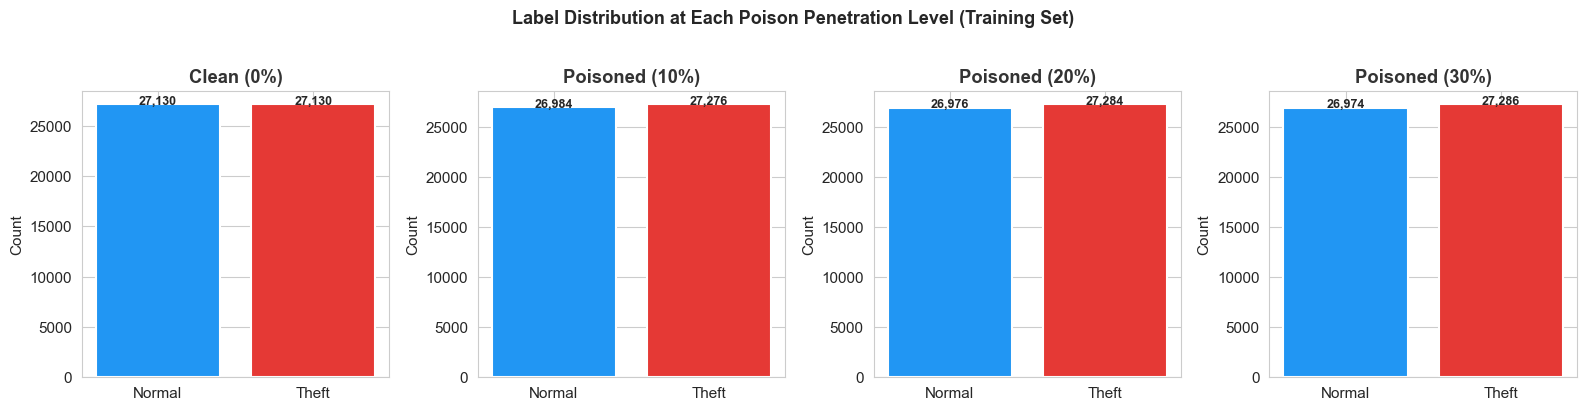

  Saved: poison_injection_verification.png

   Visual verification complete — use this figure in your paper (Section 6.2)


In [62]:
# ── Visual verification of poison injection ────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
colors = ['#2196F3', '#E53935']

for ax, rate in zip(axes, POISON_RATES):
    y_pois = poisoned_labels[rate]
    counts = pd.Series(y_pois).value_counts().sort_index()
    bars = ax.bar(['Normal', 'Theft'], counts.values, color=colors, edgecolor='white', linewidth=1.5)
    
    title = 'Clean (0%)' if rate == 0 else f'Poisoned ({int(rate*100)}%)'
    ax.set_title(title, fontweight='bold', color='#333')
    ax.set_ylabel('Count')
    
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, val + 50,
                f'{val:,}', ha='center', fontsize=9, fontweight='bold')

plt.suptitle('Label Distribution at Each Poison Penetration Level (Training Set)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('poison_injection_verification.png', dpi=150, bbox_inches='tight')
plt.show()
print('  Saved: poison_injection_verification.png')
print('\n   Visual verification complete — use this figure in your paper (Section 6.2)')

## Cell 10 — Robustness Degradation Metric (Δ)

Define the Δ metric here so it's consistent across all weeks.

$$\Delta = \text{Performance}_{\text{clean}} - \text{Performance}_{\text{poisoned}}$$

A higher Δ means the model degrades more under attack → less robust.  
A lower Δ means the model is more resilient.

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
#  ROBUSTNESS DEGRADATION METRIC — Δ
# ══════════════════════════════════════════════════════════════════════════════

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix
)

def evaluate_model(model, X_test, y_test, model_name='Model', poison_rate=0.0):
    """
    Evaluate a trained model and return all 8 metrics.
    
    Returns dict with: DR, Precision, Recall, F1, Accuracy, AUC, FPR
    """
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else y_pred
    
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    
    metrics = {
        'Model'      : model_name,
        'Poison_Rate': f'{int(poison_rate*100)}%',
        'DR'         : recall_score(y_test, y_pred),          # Detection Rate = Recall
        'Precision'  : precision_score(y_test, y_pred),
        'Recall'     : recall_score(y_test, y_pred),
        'F1'         : f1_score(y_test, y_pred),
        'Accuracy'   : accuracy_score(y_test, y_pred),
        'AUC'        : roc_auc_score(y_test, y_proba),
        'FPR'        : fp / (fp + tn)                         # False Positive Rate
    }
    return metrics


def compute_delta(results_df, metric='F1'):
    """
    Compute robustness degradation Δ for each model.
    Δ = Clean performance (0%) − Poisoned performance
    
    Args:
        results_df : DataFrame from evaluate_model results
        metric     : which metric to compute Δ on (default: F1)
    Returns:
        DataFrame with Δ values per model per poison level
    """
    delta_rows = []
    for model_name in results_df['Model'].unique():
        model_df = results_df[results_df['Model'] == model_name]
        clean_score = model_df[model_df['Poison_Rate'] == '0%'][metric].values[0]
        
        for _, row in model_df.iterrows():
            delta = clean_score - row[metric]
            delta_rows.append({
                'Model'       : model_name,
                'Poison_Rate' : row['Poison_Rate'],
                f'Delta_{metric}': round(delta, 4)
            })
    
    return pd.DataFrame(delta_rows)


print('   evaluate_model() function defined')
print('   compute_delta()   function defined')
print()
print('These functions will be used in:')
print(' Shallow ML evaluation (RF, AdaBoost, SVM)')
print(' Deep learning evaluation (GRU, AE+Attn, 1D-CNN)')
print('Ensemble evaluation (Voting, Averaging, Sequential)')

## Cell 11 — Save All Processed Data

Save everything so notebook can load directly without reprocessing.

In [ ]:
import os

# ── Create output directory ────────────────────────────────────────────────────
os.makedirs('processed_data', exist_ok=True)

# ── Save splits ────────────────────────────────────────────────────────────────
np.save('processed_data/X_train_bal.npy', X_train_bal)
np.save('processed_data/y_train_bal.npy', y_train_bal)
np.save('processed_data/X_val.npy',       X_val)
np.save('processed_data/y_val.npy',       y_val)
np.save('processed_data/X_test.npy',      X_test)
np.save('processed_data/y_test.npy',      y_test)

# ── Save poisoned label sets ───────────────────────────────────────────────────
for rate, y_pois in poisoned_labels.items():
    fname = f'processed_data/y_train_poison_{int(rate*100)}pct.npy'
    np.save(fname, y_pois)

# ── Save scaler and imputer  ─────────────────────
import pickle
with open('processed_data/scaler.pkl',  'wb') as f: pickle.dump(scaler,  f)
with open('processed_data/imputer.pkl', 'wb') as f: pickle.dump(imputer, f)

print('   All processed data saved to /processed_data/')
print()
print('  Files saved:')
for fname in sorted(os.listdir('processed_data')):
    size = os.path.getsize(f'processed_data/{fname}') / 1024
    print(f'    {fname:<45} {size:>8.1f} KB')

   All processed data saved to /processed_data/

  Files saved:
    X_test.npy                                     51344.7 KB
    X_train_bal.npy                               438319.2 KB
    X_val.npy                                      51344.7 KB
    imputer.pkl                                       20.6 KB
    scaler.pkl                                        24.7 KB
    y_test.npy                                        49.8 KB
    y_train_bal.npy                                  424.0 KB
    y_train_poison_0pct.npy                          424.0 KB
    y_train_poison_10pct.npy                         424.0 KB
    y_train_poison_20pct.npy                         424.0 KB
    y_train_poison_30pct.npy                         424.0 KB
    y_val.npy                                         49.8 KB
